# Implicit Funciton toolboox for geophysics

If we can fit a grid (or point data?) to a SIREN, we can operate directly on the Neural Network representation.


In [1]:
from pathlib import Path

import colorcet as cc
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import tifffile
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

import functorch

In [2]:
# All this cell from Sitzmann et al SIREN colab notebook, or their github repo


def get_mgrid(sidelen, dim=2):
    """Generates a flattened grid of (x,y,...) coordinates in a range of -1 to 1.
    sidelen: int
    dim: int"""
    tensors = tuple(dim * [torch.linspace(-1, 1, steps=sidelen)])
    mgrid = torch.stack(torch.meshgrid(*tensors, indexing="ij"), dim=-1)
    mgrid = mgrid.reshape(-1, dim)
    return mgrid


class SineLayer(nn.Module):
    # See paper sec. 3.2, final paragraph, and supplement Sec. 1.5 for discussion of omega_0.

    # If is_first=True, omega_0 is a frequency factor which simply multiplies the activations before the
    # nonlinearity. Different signals may require different omega_0 in the first layer - this is a
    # hyperparameter.

    # If is_first=False, then the weights will be divided by omega_0 so as to keep the magnitude of
    # activations constant, but boost gradients to the weight matrix (see supplement Sec. 1.5)

    def __init__(
        self, in_features, out_features, bias=True, is_first=False, omega_0=30
    ):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first

        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)

        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)
            else:
                self.linear.weight.uniform_(
                    -np.sqrt(6 / self.in_features) / self.omega_0,
                    np.sqrt(6 / self.in_features) / self.omega_0,
                )

    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))

    def forward_with_intermediate(self, input):
        # For visualization of activation distributions
        intermediate = self.omega_0 * self.linear(input)
        return torch.sin(intermediate), intermediate


class Siren(nn.Module):
    def __init__(
        self,
        in_features,
        hidden_features,
        hidden_layers,
        out_features,
        outermost_linear=False,
        first_omega_0=30,
        hidden_omega_0=30.0,
    ):
        super().__init__()

        self.net = []
        self.net.append(
            SineLayer(
                in_features, hidden_features, is_first=True, omega_0=first_omega_0
            )
        )

        for i in range(hidden_layers):
            self.net.append(
                SineLayer(
                    hidden_features,
                    hidden_features,
                    is_first=False,
                    omega_0=hidden_omega_0,
                )
            )

        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)

            with torch.no_grad():
                final_linear.weight.uniform_(
                    -np.sqrt(6 / hidden_features) / hidden_omega_0,
                    np.sqrt(6 / hidden_features) / hidden_omega_0,
                )

            self.net.append(final_linear)
        else:
            self.net.append(
                SineLayer(
                    hidden_features,
                    out_features,
                    is_first=False,
                    omega_0=hidden_omega_0,
                )
            )

        self.net = nn.Sequential(*self.net)

    def forward(self, coords):
        # coords = (
        #     coords.clone().detach().requires_grad_(True)
        # )  # allows to take derivative w.r.t. input
        output = self.net(coords)
        return output, coords

    def forward_with_activations(self, coords, retain_grad=False):
        """Returns not only model output, but also intermediate activations.
        Only used for visualizing activations later!"""
        activations = OrderedDict()

        activation_count = 0
        x = coords.clone().detach().requires_grad_(True)
        activations["input"] = x
        for i, layer in enumerate(self.net):
            if isinstance(layer, SineLayer):
                x, intermed = layer.forward_with_intermediate(x)

                if retain_grad:
                    x.retain_grad()
                    intermed.retain_grad()

                activations[
                    "_".join((str(layer.__class__), "%d" % activation_count))
                ] = intermed
                activation_count += 1
            else:
                x = layer(x)

                if retain_grad:
                    x.retain_grad()

            activations["_".join((str(layer.__class__), "%d" % activation_count))] = x
            activation_count += 1

        return activations


def gradient(z, xy, grad_outputs=None):
    if grad_outputs is None:
        grad_outputs = torch.ones_like(z)
    grad = torch.autograd.grad(z, [xy], grad_outputs=grad_outputs, create_graph=True)[0]
    return grad


def divergence(z, xy):
    div = 0.0
    for i in range(z.shape[-1]):
        div += torch.autograd.grad(
            z[..., i], xy, torch.ones_like(z[..., i]), create_graph=True
        )[0][..., i : i + 1]
    return div


def laplace(z, xy):
    grad = gradient(z, xy)
    return divergence(grad, xy)


def s_jacobian(z, xy):
    """jacobian of z wrt x"""
    meta_batch_size, num_observations = z.shape[:2]
    jac = torch.zeros(meta_batch_size, num_observations, z.shape[-1], xy.shape[-1]).to(
        z.device
    )  # (meta_batch_size*num_points, 2, 2)
    for i in range(z.shape[-1]):
        # calculate dydx over batches for each feature value of y
        z_flat = z[..., i].view(-1, 1)
        jac[:, :, i, :] = torch.autograd.grad(
            z_flat, xy, torch.ones_like(z_flat), create_graph=True
        )[0]

    status = 0
    if torch.any(torch.isnan(jac)):
        status = -1

    return jac, status


In [3]:
## The non-vectorised way:
## init "identity" array filled with 0
# jac = torch.zeros(meta_batch_size, num_observations, pred_z.shape[-1], xy_coord.shape[-1]).to(pred_z.device) # (meta_batch_size*num_points, 2, 2)

## Iterate for each OUTPUT data channel (coord)
# for each output channel (variable):
# > calculate dydx over batches for each feature value of y
# y_flat = pred_z[...,i].view(-1, 1)

## fill the diagonal(?) with
# jac[:, :, i, :] = torch.autograd.grad(y_flat, xy_coord, torch.ones_like(y_flat), create_graph=True)[0]


In [4]:
def naprstek2grid(n_file):
    """Load Synthetic dataset of Naprstek and Smith (2019) (per their GitHub repo)"""
    grid = np.loadtxt(n_file, skiprows=1, dtype=np.float32)
    return (
        torch.from_numpy(grid[:, 2]).reshape(1, 600, 600).transpose(2, 1).contiguous()
    )

def plt_cntr(z):
    im = plt.imshow(z, origin="lower", cmap=cc.cm.CET_L1)
    cset = plt.contour(z, np.linspace(z.min(), z.max(), 10), linewidths=2, cmap=cc.cm.CET_R2)
    plt.clabel(cset, inline=True, fmt="%1.1f", fontsize=10)
    plt.colorbar(im)

In [5]:
class PointData(Dataset):
    """Construct a dataset for SIREN comprising point coordinates and point values
    This can be from a variety of sources, using the gen_from_* methods

    """

    def __init__(self):
        super().__init__()

    def _read_file(self, grid_path):
        """Read file and return 3 channel C, H, W array"""
        if "tif" in str(grid_path.suffix).lower():
            self.grid = torch.from_numpy(tifffile.imread(grid_path))
        elif "ers" in str(grid_path.suffix).lower():
            self.grid = torch.from_numpy(rasterio.open(grid_path).read())
        elif "naprstek" in str(grid_path).lower():
            self.grid = naprstek2grid(grid_path)
        else:
            NotImplementedError(f"{grid_path.suffix()} not supported.")
        if self.grid.ndim != 3:
            raise ValueError(f"Expected 3 channels, got {self.grid.shape}")
        self.original_grid = self.grid

    def _make_square(self, mode="crop"):
        """Crop to square, removing RHS or bottom(?)"""
        self.original_shape = self.grid.shape
        if mode == "crop":
            self.grid = self.grid[
                :, : min(self.grid.shape[1:]), : min(self.grid.shape[1:])
            ].contiguous()
        elif mode == "pad":
            _, h, w = self.grid.shape
            pad_h = max(0, w - h)
            pad_w = max(0, h - w)
            self.grid = torch.nn.functional.pad(
                self.grid, (0, pad_w, 0, pad_h), "constant", 0
            ).contiguous()  # 0 is mean at this point (probably)

    def gen_from_grid(self, grid_path):
        """Load and normalise C, H, W grid to Tensor"""
        self._read_file(grid_path)
        self._normalise()
        if self.grid.shape[-1] != self.grid.shape[-2]:
            self._make_square(mode="pad")  # crop
        self.coords = get_mgrid(self.grid.shape[-1], 2)
        self.pixels = self.grid.permute(1, 2, 0).view(-1, 1)
        self.s = self.grid.shape[-1]

        return self.coords, self.pixels  # in case using method directly

    def gen_from_points(self, coords, pixels):
        """Load and normalise pregenerated coords and values."""
        self.coords = coords
        self.pixels = pixels
        self.grid = self.pixels  # for compatibility with self.normalise()
        self.original_grid = self.grid.reshape(self.s,self.s)
        self.original_shape = self.original_grid.shape
        self._normalise()
        return self.coords, self.pixels  # in case using method directly

    def _normalise(self):
        self._min = self.grid.min()
        self._max = self.grid.max()
        self.grid = (self.grid - self._min) / (self._max - self._min)
        self.pixels = self.grid

    def _unnormalise(self, data):
        return data * (self._max - self._min) + self._min

    def __len__(self):
        return 1

    def __getitem__(self, idx):
        if idx > 0:
            raise IndexError
        return self.coords, self.pixels


{'Naprstek_BaseModel1-AllValues-1nTNoise': WindowsPath('data/Naprstek_BaseModel1-AllValues-1nTNoise.txt'), 'noddyverse_95': WindowsPath('data/noddyverse_95.tif'), 'P1134-grid-tmi': WindowsPath('data/P1134-grid-tmi.ers')}
torch.Size([32400, 2])
torch.Size([32400, 1])


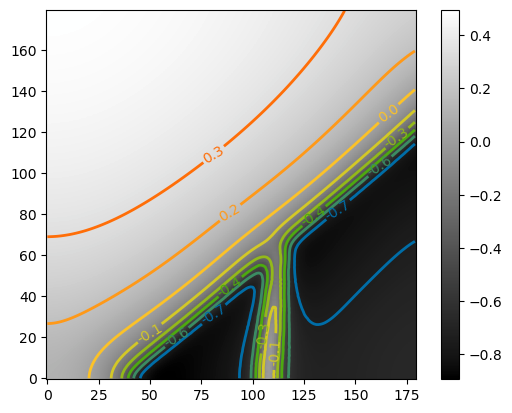

In [6]:
## Geophysics function sample:

data_dir = Path("data")
data_samples = {
    f.stem: f for f in data_dir.iterdir() if "." in str(f)
}  # handle ers data
print(data_samples)
sample = data_samples["noddyverse_95"]
zoom = (0, 200, 0, 200)

# sample = data_samples["P1134-grid-tmi"]
# zoom = (260, 420, 110, 190)

# sample = Path(data_samples["Naprstek_BaseModel1-AllValues-1nTNoise"])
# zoom = (0, 600, 0, 600)

dset = PointData()
coords, pixels = dset.gen_from_grid(sample)
coords = coords.requires_grad_(True)
print(coords.shape)
print(pixels.shape)


plt_cntr(dset.original_grid.squeeze())

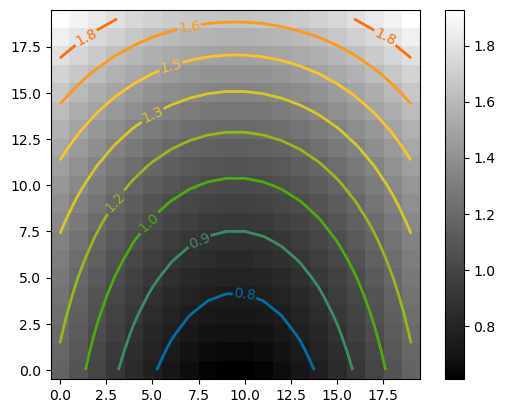

In [7]:
## Custom Function sample:
d = 20
x, y = np.meshgrid(np.linspace(-1, 1, d), np.linspace(-1, 1, d), indexing="xy")
z = np.sqrt(x**2 + np.exp(y))
plt_cntr(z)

## PointData for custom Fn
dset = PointData()
dset.s = len(x)
coords = torch.tensor(np.stack((x.flatten(), y.flatten()), axis=1), dtype=torch.float32)
pixels = torch.tensor(z.flatten(), dtype=torch.float32).unsqueeze(1)
coords, pixels = dset.gen_from_points(coords, pixels)
coords = coords.requires_grad_(True)


In [8]:
dataloader = DataLoader(dset, batch_size=1, pin_memory=True, num_workers=0)

device = "cuda"

img_siren = Siren(
    in_features=2,
    out_features=1,
    hidden_features=256,
    hidden_layers=3,
    outermost_linear=True,
)
img_siren.to(device)

model_input, ground_truth = next(iter(dataloader))
model_input, ground_truth = model_input.to(device), ground_truth.to(device)


  0%|          | 0/4000 [00:00<?, ?it/s]

Step 3999, Total loss 0.000000


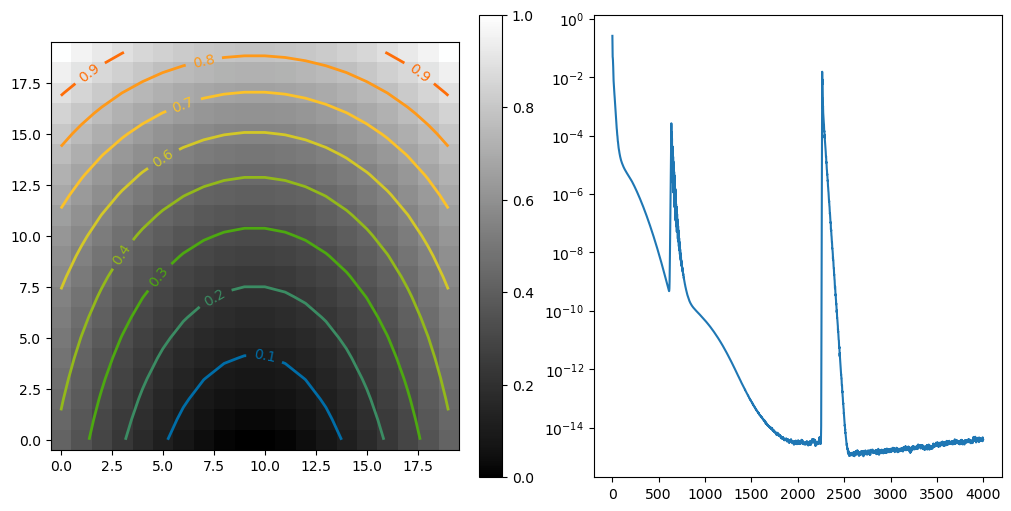

In [9]:
total_steps = 4000  # 4000  # Since the whole image is our dataset, this just means n gradient descent steps.
summary_steps = [1000000, total_steps - 1]

optim = torch.optim.Adam(lr=1e-4, params=img_siren.parameters())
losses = []

for step in tqdm(range(total_steps)):
    model_output, coords = img_siren(model_input)
    loss = ((model_output - ground_truth) ** 2).mean()
    losses.append(loss.item())

    if step in summary_steps:
        print("Step %d, Total loss %0.6f" % (step, loss))
        img_grad = gradient(model_output, coords)
        z = model_output.cpu().view(dset.s, dset.s).detach().numpy()
        #     img_laplacian = laplace(model_output, coords)
        plt.figure(constrained_layout=True, figsize=(10, 5))
        plt.subplot(1,2,1)
        plt_cntr(z)
        plt.subplot(1,2,2)
        plt.plot(losses)
        plt.semilogy()

    optim.zero_grad()
    loss.backward()
    optim.step()

# 600x600, 500 iters, 25 sec, BUT laplacian too much ram


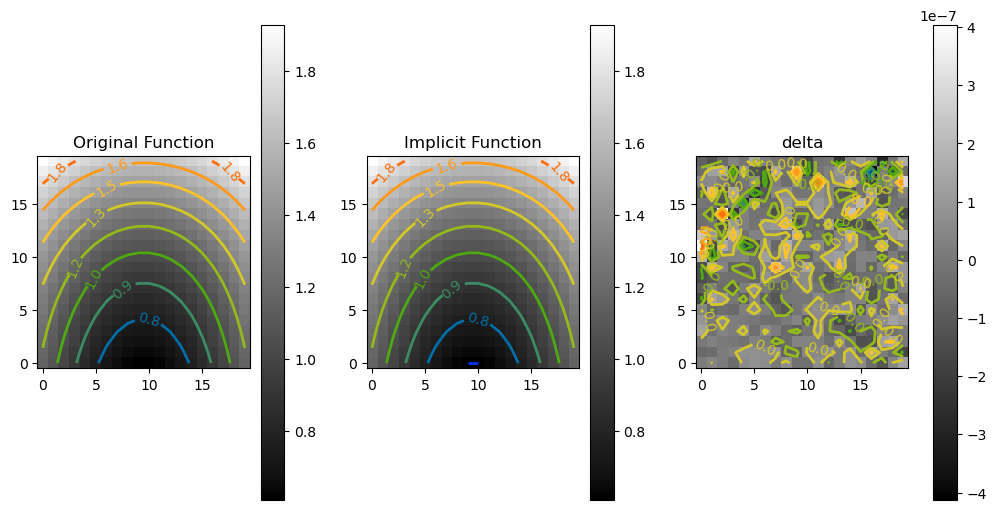

In [10]:
x, y = np.meshgrid(np.linspace(-1, 1, d), np.linspace(-1, 1, d), indexing="xy")
z = np.sqrt(x**2 + np.exp(y))

pred_z, xy_coord = img_siren(model_input)
pred_z = dset._unnormalise(pred_z)

plt.figure(constrained_layout=True, figsize=(10, 5))
plt.subplot(1,3,1)
plt.title("Original Function")
plt_cntr(z)
plt.subplot(1,3,2)
plt.title("Implicit Function")
plt_cntr(pred_z.detach().cpu().view(dset.s, dset.s).numpy())

plt.subplot(1,3,3)
plt.title("delta")
plt_cntr(z - pred_z.detach().cpu().view(dset.s, dset.s).numpy())

So we've established that an Implicit function such as SIREN can learn a grid extent quite well.  
Now we want to calculate the gradients (Jacobian) using the network.  
We do this as a calculation of the gradients between the model inputs (x,y) and the model output (z) which is the TMI at that x,y point.

There are several ways to calculate the Jacobian:  
1. `torch.autograd.functional.jacobian(vectorized=True)`
1. `torch.autograd.grad(is_grads_batched=True)`
1. `functorch.jacrev`

https://github.com/pytorch/pytorch/issues/23475#issuecomment-946927242

We want the Jacobian: $$J(x,y) = [\frac{\partial{z(x,y)}}{\partial{x}}, \frac{\partial{z(x,y)}}{\partial{y}}]$$

Where $$ z = f(x,y)\,,\, f:R^2 \to R^1$$
This is the special case where _the Jacobian matrix reduces to the row vector $${\displaystyle \nabla ^{\mathrm {T} }f}$$ this row vector of all first-order partial derivatives of f is the transpose of the gradient of f $${\displaystyle \mathbf {J} _{f}=\nabla ^{T}f}. $$_



In [ ]:
from functorch import vmap, vjp, jacrev

vmap(jacrev(img_siren))(model_input)

In [ ]:
j = (dzdx, dzdy) = torch.autograd.functional.jacobian(lambda t: img_siren(t), model_input)

In [ ]:
j[0].shape

In [ ]:
## Sitzmann et al. method (non vectorised)
meta_batch_size = pred_z.shape[0]  # only 1 tile
num_observations = pred_z.shape[1]  # Num XYZ points,
out_vecs = pred_z.shape[-1]  # num output channels, 1
in_ch = xy_coord.shape[-1]  # num input channels, 2

jac = torch.zeros(meta_batch_size, num_observations, out_vecs, in_ch).to(
    pred_z.device
)  # (meta_batch_size*num_points, 2, 2)
for vec in range(out_vecs):
    # calculate dydx over batches for each feature value of y
    y_flat = pred_z[..., vec].view(-1, 1)
    jac[:, :, vec, :] = torch.autograd.grad(
        y_flat, xy_coord, torch.ones_like(y_flat), create_graph=True
    )[0]


In [ ]:
jac.shape

In [ ]:
jac2 = jac.squeeze().reshape(20,20,2).permute(2,0,1)[1]
plt.imshow(jac2.detach().cpu().numpy())
plt.colorbar()

In [ ]:
from functorch import vmap, vjp, jacrev

def f(x):
    return img_siren(x)

j = jacrev(f)(model_input.squeeze())

In [ ]:
print(model_input.squeeze().shape)
print(f"{j[0].shape=}")
print(f"{j[1].shape=}")

In [ ]:
j[1]

In [ ]:
## As of pytorch 1.13, we can now use functorch operations
## https://pytorch.org/functorch/stable/notebooks/jacobians_hessians.html

# from functorch import vmap, vjp, jacfwd, jacrev
# torch.manual_seed(0)

# img_siren

# m = model_input.clone().requires_grad_()

# cotangents = torch.eye(m.shape[1])
# _, vjp_fn = vjp((img_siren), m)
# vmap(vjp_fn)(cotangents)

# # ft_jacobian = jacrev(img_siren, argnums=(0,))(m)

# # ft_jacobian = vmap(jacrev(img_siren, argnums = 0), in_dims=(None, 0, None))
# # btach_jac = ft_jacobian( )


In [ ]:
# model_output, coords = img_siren(model_input)
# print(f"{model_input.shape=}")
# print(f"{img_siren(model_input)[0].shape=}")
# print(f"{img_siren(model_input)[1].shape=}")

# j = torch.autograd.functional.jacobian(lambda x: img_siren(x)[0], model_input, vectorize=True)
# j2 = torch.diagonal(j, offset=0, dim1=0, dim2=2)
# j3 = j2.permute(2,0,1)

# j2.shape
# j.squeeze()[1].reshape(s, s, 2).shape


In [ ]:
def gradients(pred_z, xy_coord):
    """Compute the xx and yy gradients of the Implicit Function
    When trained, inputs of (x,y) coords to a Siren model (F) return "g"
    value outputs.
    Generally, this is g = F(x,y)
    """
    dzdy, dzdx = (
        torch.autograd.grad(
            pred_z,
            [xy_coord],
            grad_outputs=torch.ones_like(pred_z),
            create_graph=True,
        )[0]
        .detach()
        .view(dset.s, dset.s, 2)
        .permute(2, 0, 1)
        .cpu()
    )  # what is [0] doing?

    return dzdy, dzdx


def jacobian(pred_z, xy_coord):
    """Compute the Jacobian of the Implicit Function
    torch.autograd.grad() returns a slightly different product than the Jacobian,
    according to ... ?
    """
    return NotImplementedError


# Below references are per Blakely, R. J. 1996
# _Potential Theory in Gravity and Magnetic Applications_
# Cambridge University Press


def horizontal_gradient(dzdy, dzdx):
    """Horizontal Gradient, eqn 12.49"""
    # return torch.sqrt(dzdx ** 2 + dzdy ** 2)
    return torch.dstack((dzdy, dzdx)).norm(dim=-1, p="fro")


def upward_continuation():
    """Upward Continuation, eqn 12.4"""
    return NotImplementedError


def downward_continuation(dz):
    """Downward Continuation, eqn 12.5
    args:
        - dz: vertical distance to downward continue


    (dz / 2 * pi) * double integral (output_xyz0) / ((x-x')^2 + (y-y')^2 + (dz**2))**(3/2) dxdy

    """

    return NotImplementedError


def vertical_derivative(order=1):
    """Vertical Derivative, eqn 12.17
    Args:
        order (int): Order of derivative, e.g. 2 for 2VD

    """
    return NotImplementedError


In [ ]:
pred_z, xy_coord = img_siren(model_input)
dzdy, dzdx = gradients(torch.from_numpy(z).requires_grad_(True), xy_coord)
horiz_g = horizontal_gradient(dzdy, dzdx)


In [ ]:
####
# You were trying to calculate the derivatives of the input function from Tom, but have begun an interest in the above error - re: if the points here are hanging onto the "graph"

In [ ]:
crop = dset.original_shape
# w,e,s,n = (0, crop[-2], 0, crop[-1])
w, e, s, n = zoom


In [ ]:
zoom

In [ ]:
import matplotlib.colors as colors

fig, axs = plt.subplots(3, 2, layout="constrained", figsize=(10, 12))
plt.suptitle(f"Horizontal Derivatives - {sample.stem}")
plt_opts = dict(origin="upper", cmap=cc.cm.CET_L1)
[[axg, axp], [axx, axy], [axh, axoff]] = axs

axg.set_title(r"Original TMI Grid")
caxi = axg.imshow(dset.original_grid.squeeze()[s:n, w:e], cmap=cc.cm.CET_L1)
plt.colorbar(mappable=caxi, ax=axg, label=r"nT", location="bottom")

axp.set_title(r"Learnt TMI Grid")
caxp = axp.imshow(
    pred_z.detach().cpu().view(dset.s, dset.s).squeeze()[s:n, w:e], cmap=cc.cm.CET_L1
)
plt.colorbar(mappable=caxp, ax=axp, label=r"nT", location="bottom")

axh.set_title(r"Horizontal gradient")
caxh = axh.imshow(horiz_g[s:n, w:e], cmap=cc.cm.CET_L1, vmin=0, vmax=10)
plt.colorbar(mappable=caxh, ax=axh, label=r"nT/cell", location="bottom")

axx.set_title(r"$\delta$z$\delta$x")
caxx = axx.imshow(dzdx[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxx, ax=axx, label=r"nT/cell", location="bottom")

axy.set_title(r"$\delta$z$\delta$y")
caxy = axy.imshow(dzdy[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxy, ax=axy, label=r"nT/cell", location="bottom")

# norm = colors.LogNorm(vmin=0.1, vmax=60)
axoff.axis("off")

for ax in axs.ravel():
    ax.set_xlabel("x")
    ax.set_ylabel("y")
